# Part IV: Sentiment analysis using LSTM [20 points]
In this part, we perform a sentiment analysis using LSTM model. The final (improved) model should achieve a test accuracy of greater than 75%.

## Step 1: Data exploration and preprocessing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bz2
from collections import Counter
import torch
import re
import numpy as np
from collections import Counter
from tqdm import tqdm
import string
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader

1. Load your chosen dataset and print the main statistics

In [3]:
def load_dataset(file_path):
    with bz2.BZ2File(file_path, 'r') as f:
        dataset = [line.decode('utf-8').strip() for line in f.readlines()]
    return dataset

In [34]:
test_dataset = load_dataset("/kaggle/input/amazonreviews/test.ft.txt.bz2")
train_dataset = load_dataset("/kaggle/input/amazonreviews/train.ft.txt.bz2")

print(len(train_dataset),len(test_dataset))

3600000 400000


2. Print the first 5 rows of the dataset to understand its structure

In [36]:
for i in range(5):
    print(train_dataset[i])

__label__2 Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
__label__2 The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.
__label__2 Amazing!: This soundtrack is m

3. Provide a brief description of the dataset

<span style='color:green'>ans.</span>

The Amazon Reviews Dataset contains a collection of product reviews from Amazon. It is derived from a larger dataset prepared for sentiment analysis tasks. Here’s a brief description:

Dataset Overview:
The dataset consists of Amazon product reviews along with sentiment labels.
Each line in the dataset represents a single review, prefixed by a sentiment label (__label__1 or __label__2).
__label__1 corresponds to 1- and 2-star reviews, and __label__2 corresponds to 4- and 5-star reviews.
The dataset is compressed using BZ2 format to reduce file size.

Structure of the Data:
Each row follows this format:

__label__2 This product is amazing! I highly recommend it.

__label__1 The quality was terrible and it broke within a week.

The first token (__label__1 or __label__2) is the sentiment label.
The rest of the line is the review text.

4. Display descriptive statistics

In [37]:
num_samples = len(train_dataset)

label_counts = Counter(line.split()[0] for line in train_dataset)
total_labels = sum(label_counts.values())
class_distribution = {label: (count / total_labels) * 100 for label, count in label_counts.items()}

review_lengths_words = [len(line.split()) - 1 for line in train_dataset] 
review_lengths_chars = [len(line) - len(line.split()[0]) for line in train_dataset]  

avg_review_length_words = np.mean(review_lengths_words)
avg_review_length_chars = np.mean(review_lengths_chars)

unique_words = set()
for line in train_dataset:
    words = line.split()[1:]
    unique_words.update(words)

vocab_size = len(unique_words)

print("Descriptive Statistics for Amazon Reviews - Train Dataset:")
print(f"• Number of Samples: {num_samples}")
print(f"• Class Distribution: {class_distribution}")
print(f"• Average Review Length (Words): {avg_review_length_words:.2f}")
print(f"• Average Review Length (Characters): {avg_review_length_chars:.2f}")
print(f"• Vocabulary Size: {vocab_size}")

Descriptive Statistics for Amazon Reviews - Train Dataset:
• Number of Samples: 3600000
• Class Distribution: {'__label__2': 50.0, '__label__1': 50.0}
• Average Review Length (Words): 78.48
• Average Review Length (Characters): 432.65
• Vocabulary Size: 5165172


In [38]:
num_samples = len(test_dataset)

label_counts = Counter(line.split()[0] for line in test_dataset)
total_labels = sum(label_counts.values())
class_distribution = {label: (count / total_labels) * 100 for label, count in label_counts.items()}

review_lengths_words = [len(line.split()) - 1 for line in test_dataset] 
review_lengths_chars = [len(line) - len(line.split()[0]) for line in test_dataset]  

avg_review_length_words = np.mean(review_lengths_words)
avg_review_length_chars = np.mean(review_lengths_chars)

unique_words = set()
for line in test_dataset:
    words = line.split()[1:]
    unique_words.update(words)

vocab_size = len(unique_words)

print("Descriptive Statistics for Amazon Reviews - Test Dataset:")
print(f"• Number of Samples: {num_samples}")
print(f"• Class Distribution: {class_distribution}")
print(f"• Average Review Length (Words): {avg_review_length_words:.2f}")
print(f"• Average Review Length (Characters): {avg_review_length_chars:.2f}")
print(f"• Vocabulary Size: {vocab_size}")

Descriptive Statistics for Amazon Reviews - Test Dataset:
• Number of Samples: 400000
• Class Distribution: {'__label__2': 50.0, '__label__1': 50.0}
• Average Review Length (Words): 78.42
• Average Review Length (Characters): 432.43
• Vocabulary Size: 1077182


5. Handle missing values

In [39]:
missing_count_train = sum(1 for line in train_dataset if not line or len(line.split()) < 2)
cleaned_train_dataset = [line for line in train_dataset if line and len(line.split()) >= 2]

print(f"Original dataset size: {len(train_dataset)}")
print(f"Number of missing or malformed entries: {missing_count_train}")
print(f"Cleaned dataset size: {len(cleaned_train_dataset)}")

Original dataset size: 3600000
Number of missing or malformed entries: 0
Cleaned dataset size: 3600000


In [40]:
missing_count_test = sum(1 for line in test_dataset if not line or len(line.split()) < 2)
cleaned_test_dataset = [line for line in test_dataset if line and len(line.split()) >= 2]

print(f"Original dataset size: {len(test_dataset)}")
print(f"Number of missing or malformed entries: {missing_count_test}")
print(f"Cleaned dataset size: {len(cleaned_test_dataset)}")

Original dataset size: 400000
Number of missing or malformed entries: 0
Cleaned dataset size: 400000


6. Create visualizations to gain insights into the data

In [41]:
!pip3 install wordcloud

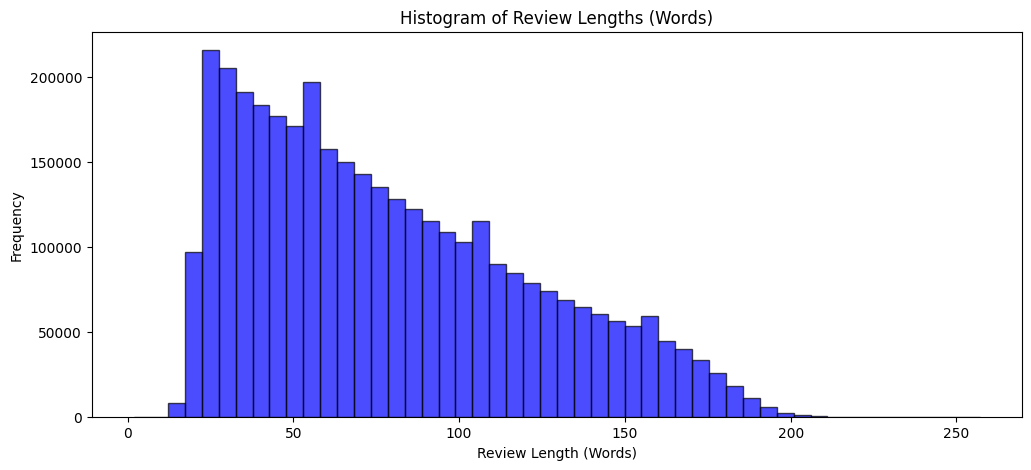

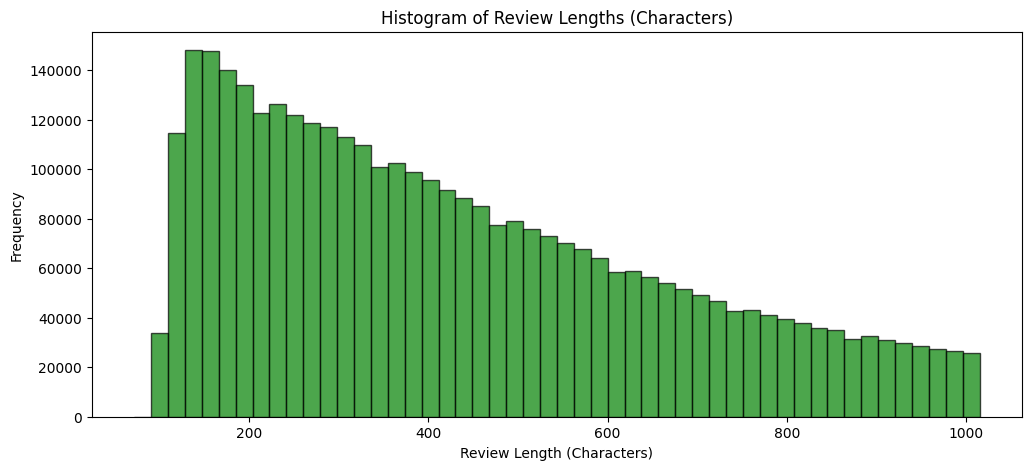

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


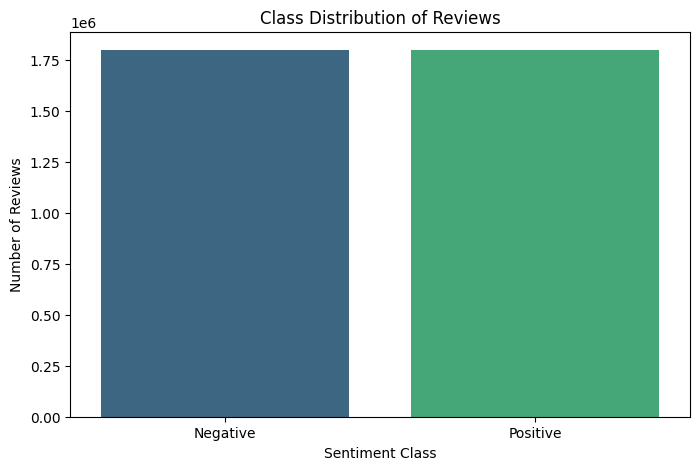

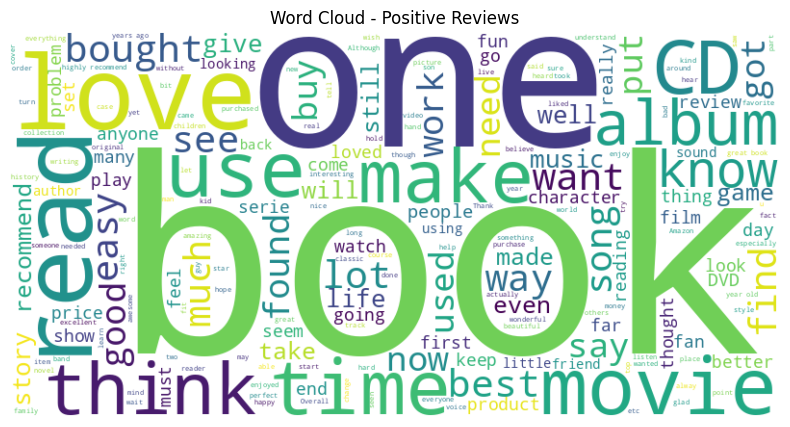

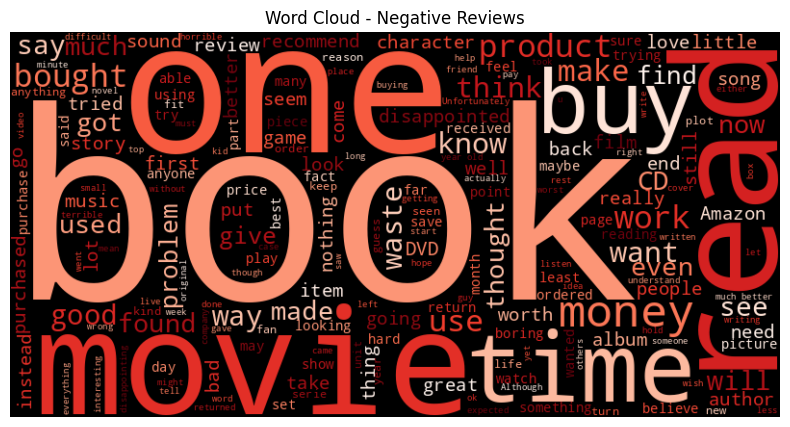

In [42]:
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

try:
    cleaned_dataset = cleaned_train_dataset

    labels = [line.split()[0] for line in cleaned_dataset]
    reviews = [" ".join(line.split()[1:]) for line in cleaned_dataset]

    review_lengths_words = [len(review.split()) for review in reviews]
    review_lengths_chars = [len(review) for review in reviews]

    plt.figure(figsize=(12, 5))
    plt.hist(review_lengths_words, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.xlabel("Review Length (Words)")
    plt.ylabel("Frequency")
    plt.title("Histogram of Review Lengths (Words)")
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.hist(review_lengths_chars, bins=50, alpha=0.7, color='green', edgecolor='black')
    plt.xlabel("Review Length (Characters)")
    plt.ylabel("Frequency")
    plt.title("Histogram of Review Lengths (Characters)")
    plt.show()

    # Class distribution bar chart
    label_counts = Counter(labels)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()), palette="viridis")
    plt.xlabel("Sentiment Class")
    plt.ylabel("Number of Reviews")
    plt.title("Class Distribution of Reviews")
    plt.xticks(ticks=[0, 1], labels=["Negative", "Positive"])
    plt.show()

    # Generate word clouds for each sentiment class
    positive_reviews = " ".join([reviews[i] for i in range(len(reviews)) if labels[i] == "__label__2"])
    negative_reviews = " ".join([reviews[i] for i in range(len(reviews)) if labels[i] == "__label__1"])

    wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
    wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap="Reds").generate(negative_reviews)

    # Display word clouds
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_pos, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud - Positive Reviews")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_neg, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud - Negative Reviews")
    plt.show()

except FileNotFoundError:
    print("Dataset file not found. Please upload the dataset or check the file path.")

7. Data preparation

In [4]:
dataset = load_dataset("/kaggle/input/amazonreviews/test.ft.txt.bz2")

In [5]:
def preprocess_text_and_labels(data):
    labels = [0 if x.split(" ")[0] == "__label__1" else 1 for x in data]
    texts = [x.split(" ", 1)[1][:-1].lower() for x in data]
    texts = [re.sub("\d", "0", text) for text in texts]  
    return labels, texts

labels, processed_texts = preprocess_text_and_labels(dataset)

In [6]:
print("Sample processed text:", processed_texts[0])

Sample processed text: great cd: my lovely pat has one of the great voices of her generation. i have listened to this cd for years and i still love it. when i'm in a good mood it makes me feel better. a bad mood just evaporates like sugar in the rain. this cd just oozes life. vocals are jusat stuunning and lyrics just kill. one of life's hidden gems. this is a desert isle cd in my book. why she never made it big is just beyond me. everytime i play this, no matter black, white, young, old, male, female everybody says one thing "who was that singing ?


In [6]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
def build_vocabulary(texts, min_occurrence_threshold=1):
    word_counter = Counter()
    for sentence in tqdm(texts, desc="Tokenizing Sentences"):
        for word in nltk.word_tokenize(sentence):
            word_counter.update([word.lower()])
    
    filtered_words = {k: v for k, v in word_counter.items() if v > min_occurrence_threshold}
    sorted_words = sorted(filtered_words, key=filtered_words.get, reverse=True)
    vocabulary = ["_PAD", "_UNK"] + sorted_words  
    
    word_to_index = {word: idx for idx, word in enumerate(vocabulary)}
    index_to_word = {idx: word for word, idx in word_to_index.items()}
    
    return word_to_index, index_to_word

word_to_index, index_to_word = build_vocabulary(processed_texts)
print("Vocabulary size: ", len(word_to_index))

Tokenizing Sentences: 100%|██████████| 400000/400000 [04:20<00:00, 1536.05it/s]


Vocabulary size:  150094


In [8]:
def text_to_sequences(texts, word_to_index):
    sequences = []
    for sentence in tqdm(texts, desc="Converting Text to Sequences"):
        indices = [word_to_index.get(word, 1) for word in nltk.word_tokenize(sentence)]
        sequences.append(indices)
    return sequences

numerical_sequences = text_to_sequences(processed_texts, word_to_index)

Converting Text to Sequences: 100%|██████████| 400000/400000 [03:56<00:00, 1692.13it/s]


In [9]:
def pad_sequences(sequences, seq_length):
    padded_features = np.zeros((len(sequences), seq_length), dtype=int)
    for i, sequence in enumerate(tqdm(sequences, desc="Padding Sequences")):
        if len(sequence) != 0:
            padded_features[i, -len(sequence):] = np.array(sequence)[:seq_length]
    return padded_features

SEQUENCE_LENGTH = 230
padded_sequences = pad_sequences(numerical_sequences, SEQUENCE_LENGTH)

Padding Sequences: 100%|██████████| 400000/400000 [00:03<00:00, 117827.89it/s]


In [10]:
print("Sample text input: ", padded_sequences[0])

Sample text input:  [     0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0     38    109     13     28   1574
   4454     56     31     10      2     38   1919     10     92   1937
      3      5     26    993      8     11    109     15    150      6
      5    138     95      9      3     63      5    123 

8. Split dataset into train, validation, and test sets

In [11]:
def split_dataset(features, labels, train_ratio=0.8, val_ratio=0.1):
    total_samples = len(features)
    train_size = int(train_ratio * total_samples)
    val_size = int(val_ratio * total_samples)
    test_size = total_samples - train_size - val_size
    
    train_x, val_x, test_x = features[:train_size], features[train_size:train_size + val_size], features[train_size + val_size:]
    train_y, val_y, test_y = labels[:train_size], labels[train_size:train_size + val_size], labels[train_size + val_size:]
    
    return train_x, train_y, val_x, val_y, test_x, test_y

X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(padded_sequences, labels)

In [12]:
def create_dataloader(X_data, y_data, batch_size=64, shuffle=True):
    tensor_x = torch.tensor(X_data, dtype=torch.long)
    tensor_y = torch.tensor(y_data, dtype=torch.float)
    dataset = TensorDataset(tensor_x, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

## Step 2: Baseline LSTM Model

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


1. Build an LSTM model

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary

class BaseLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dims, output_dim, dropout_prob=0.3, n_layers=1):
        super(BaseLSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm1 = nn.LSTM(input_size=embedding_dim, 
                             hidden_size=hidden_dims[0], 
                             num_layers=n_layers, 
                             batch_first=True, 
                             dropout=dropout_prob if n_layers > 1 else 0.0)

        self.lstm2 = nn.LSTM(input_size=hidden_dims[0], 
                             hidden_size=hidden_dims[1], 
                             num_layers=n_layers, 
                             batch_first=True, 
                             dropout=dropout_prob if n_layers > 1 else 0.0)

        self.lstm3 = nn.LSTM(input_size=hidden_dims[1], 
                             hidden_size=hidden_dims[2], 
                             num_layers=n_layers, 
                             batch_first=True, 
                             dropout=dropout_prob if n_layers > 1 else 0.0)

        self.fc = nn.Linear(hidden_dims[2], output_dim)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x, _ = self.lstm3(x)
        x = x[:, -1, :]  
        x = self.fc(x)
        return self.activation(x) 

VOCAB_SIZE = len(word_to_index) + 1   
EMBEDDING_DIM = 230  
HIDDEN_DIMS = [128, 64, 32]  
OUTPUT_DIM = 1       
N_LAYERS = 3         

model = BaseLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIMS, OUTPUT_DIM, n_layers=N_LAYERS, dropout_prob=0.5).to(device)

# Print Model Summary
print(model)

BaseLSTM(
  (embedding): Embedding(150095, 230)
  (lstm1): LSTM(230, 128, num_layers=3, batch_first=True, dropout=0.5)
  (lstm2): LSTM(128, 64, num_layers=3, batch_first=True, dropout=0.5)
  (lstm3): LSTM(64, 32, num_layers=3, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (activation): Sigmoid()
)


2. Train your model

In [17]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [18]:
import torch
import torch.nn.functional as F

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    correct_train, total_train, total_loss = 0, 0, 0

    for X_batch, Y_batch in train_loader:
        
        X_batch, Y_batch = X_batch.to(device).long(), Y_batch.to(device).float()
        optimizer.zero_grad()
        output = model(X_batch)
        
        predicted_classes = (output >= 0.5).float()
        
        loss = criterion(output.squeeze(), Y_batch)
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        predicted_classes = predicted_classes.view(-1)
        Y_batch = Y_batch.view(-1)
        correct_train += (predicted_classes == Y_batch).sum().item()
        total_train += Y_batch.size(0) 
        
    return total_loss / len(train_loader), (correct_train / total_train) * 100  # Corrected accuracy calculation

def validate(model, vali_loader, criterion, device):
    model.eval()
    correct_val, total_val, total_val_loss = 0, 0, 0

    with torch.no_grad():
        for X_val, y_val in vali_loader:
            
            X_val, y_val = X_val.to(device).long(), y_val.to(device).float()
            output = model(X_val)
            
            predicted_classes = (output >= 0.5).float()
            loss = criterion(output.squeeze(), y_val)
            
            predicted_classes = predicted_classes.view(-1)
            y_val = y_val.view(-1)
            total_val_loss += loss.item()
            correct_val += (predicted_classes == y_val).sum().item()
            total_val += y_val.size(0)

    return total_val_loss / len(vali_loader), (correct_val / total_val) * 100  # Corrected accuracy calculation

In [19]:
import torch
import torch.nn.functional as F

def test_model(model, test_loader, criterion, device):
    model.eval() 
    total_correct = 0
    total_samples = 0
    cumulative_test_loss = 0

    true_labels = []  
    predicted_classes = []  
    predicted_probabilities = []  

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device).long(), targets.to(device).float()

            outputs = model(inputs)  
            predictions = (outputs >= 0.5).float()
            loss = criterion(outputs.squeeze(), targets)

            predictions = predictions.view(-1)
            targets = targets.view(-1)
            total_correct += (predictions == targets).sum().item()
            total_samples += targets.numel()
            
            cumulative_test_loss += loss.item()

            predicted_probabilities.extend(outputs.squeeze().cpu().numpy())  
            predicted_classes.extend(predictions.cpu().numpy())  
            true_labels.extend(targets.cpu().numpy())    

    avg_test_loss = cumulative_test_loss / len(test_loader)
    test_accuracy = 100 * total_correct / total_samples

    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Test Loss: {avg_test_loss:.4f}")

    return true_labels, predicted_classes, predicted_probabilities, avg_test_loss, test_accuracy


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from itertools import product

learning_rates = [0.0001, 0.001, 0.005]
batch_sizes = [32, 64]
HIDDEN_DIMS = [128, 64, 32]
dropout_rates = [0.3, 0.5]
num_epochs = 3

best_val_loss = float('inf')
best_params = None

for lr, batch_size, dropout_prob in product(
        learning_rates, batch_sizes, dropout_rates):

    print(f"\nTraining with lr={lr}, batch_size={batch_size}, num_epochs={num_epochs}, hidden_dim={HIDDEN_DIMS}, dropout={dropout_prob}")

    model = BaseLSTM(VOCAB_SIZE, EMBEDDING_DIM, 
                     HIDDEN_DIMS, OUTPUT_DIM, n_layers=N_LAYERS, dropout_prob=dropout_prob).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    train_loader = create_dataloader(X_train, y_train,batch_size=batch_size)
    val_loader = create_dataloader(X_val, y_val, batch_size=batch_size)

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = (lr, batch_size, num_epochs, HIDDEN_DIMS, dropout_prob)

print("\nBest Hyperparameters:")
print(f"Learning Rate: {best_params[0]}, Batch Size: {best_params[1]}, Num Epochs: {best_params[2]}, Hidden Dim: {best_params[3]}, Dropout: {best_params[4]}")



Training with lr=0.0001, batch_size=32, num_epochs=3, hidden_dim=[128, 64, 32], dropout=0.3
Epoch 1/3 - Train Loss: 0.5286, Train Acc: 72.88% | Val Loss: 0.4733, Val Acc: 77.90%
Epoch 2/3 - Train Loss: 0.3279, Train Acc: 86.46% | Val Loss: 0.2581, Val Acc: 89.86%
Epoch 3/3 - Train Loss: 0.2346, Train Acc: 90.80% | Val Loss: 0.2276, Val Acc: 91.15%

Training with lr=0.0001, batch_size=32, num_epochs=3, hidden_dim=[128, 64, 32], dropout=0.5
Epoch 1/3 - Train Loss: 0.6005, Train Acc: 62.22% | Val Loss: 0.3356, Val Acc: 86.05%
Epoch 2/3 - Train Loss: 0.2725, Train Acc: 88.83% | Val Loss: 0.2422, Val Acc: 90.79%
Epoch 3/3 - Train Loss: 0.2086, Train Acc: 91.88% | Val Loss: 0.1922, Val Acc: 92.57%

Training with lr=0.0001, batch_size=64, num_epochs=3, hidden_dim=[128, 64, 32], dropout=0.3
Epoch 1/3 - Train Loss: 0.5839, Train Acc: 68.66% | Val Loss: 0.4297, Val Acc: 81.03%
Epoch 2/3 - Train Loss: 0.3623, Train Acc: 84.41% | Val Loss: 0.2811, Val Acc: 88.59%
Epoch 3/3 - Train Loss: 0.2529, T

In [20]:
import time

train_loader = create_dataloader(X_train, y_train, batch_size=32)
val_loader = create_dataloader(X_val, y_val, batch_size=32)
test_loader = create_dataloader(X_test, y_test, batch_size=32)

train_loss, train_accuracy = [], []
validation_loss, validation_accuracy = [], []

best_val_loss = float('inf')
early_stopping_counter = 0
early_stopping_patience = 2
num_epochs = 5

start_training_time = time.time()

for epoch in range(num_epochs):
    
    epoch_start_time = time.time() 
    train_loss_epoch, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss_epoch, val_acc = validate(model, val_loader, criterion, device)
    epoch_end_time = time.time()  
    epoch_duration = epoch_end_time - epoch_start_time 

    train_loss.append(train_loss_epoch)
    train_accuracy.append(train_acc)
    validation_loss.append(val_loss_epoch)
    validation_accuracy.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss_epoch:.4f}, Train Accuracy: {train_acc:.2f}% | "
          f"Val Loss: {val_loss_epoch:.4f}, Val Accuracy: {val_acc:.2f}% | "
          f"Time: {epoch_duration:.2f} sec")

    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

end_training_time = time.time()
total_training_time = end_training_time - start_training_time
print(f"\nTotal Training Time: {total_training_time:.2f} sec ({total_training_time/60:.2f} min)")

Epoch [1/5] - Train Loss: 0.3605, Train Accuracy: 83.88% | Val Loss: 0.2533, Val Accuracy: 90.06% | Time: 281.54 sec
Epoch [2/5] - Train Loss: 0.2243, Train Accuracy: 91.24% | Val Loss: 0.2107, Val Accuracy: 91.84% | Time: 282.99 sec
Epoch [3/5] - Train Loss: 0.1871, Train Accuracy: 92.86% | Val Loss: 0.1892, Val Accuracy: 92.94% | Time: 283.32 sec
Epoch [4/5] - Train Loss: 0.1645, Train Accuracy: 93.89% | Val Loss: 0.1850, Val Accuracy: 93.16% | Time: 283.29 sec
Epoch [5/5] - Train Loss: 0.1473, Train Accuracy: 94.63% | Val Loss: 0.1798, Val Accuracy: 93.49% | Time: 283.32 sec

Total Training Time: 1414.46 sec (23.57 min)


In [21]:
labels_test_total, test_predictions, test_probabilities, test_loss, test_accuracy = test_model(model, test_loader, criterion, device)


Test Accuracy: 93.49%
Test Loss: 0.1814


<span style='color:green'>### YOUR ANSWER ###</span>

3. Evaluation and analysis

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

predicted_test_classes_np = np.array([prediction.item() for prediction in test_predictions])
labels_test_total_np = np.array([label.item() for label in labels_test_total])

precision = precision_score(labels_test_total_np, predicted_test_classes_np)
recall = recall_score(labels_test_total_np, predicted_test_classes_np)
f1 = f1_score(labels_test_total_np, predicted_test_classes_np)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.9486871639609542
Recall: 0.9181106339984845
F1-score: 0.9331484904497843


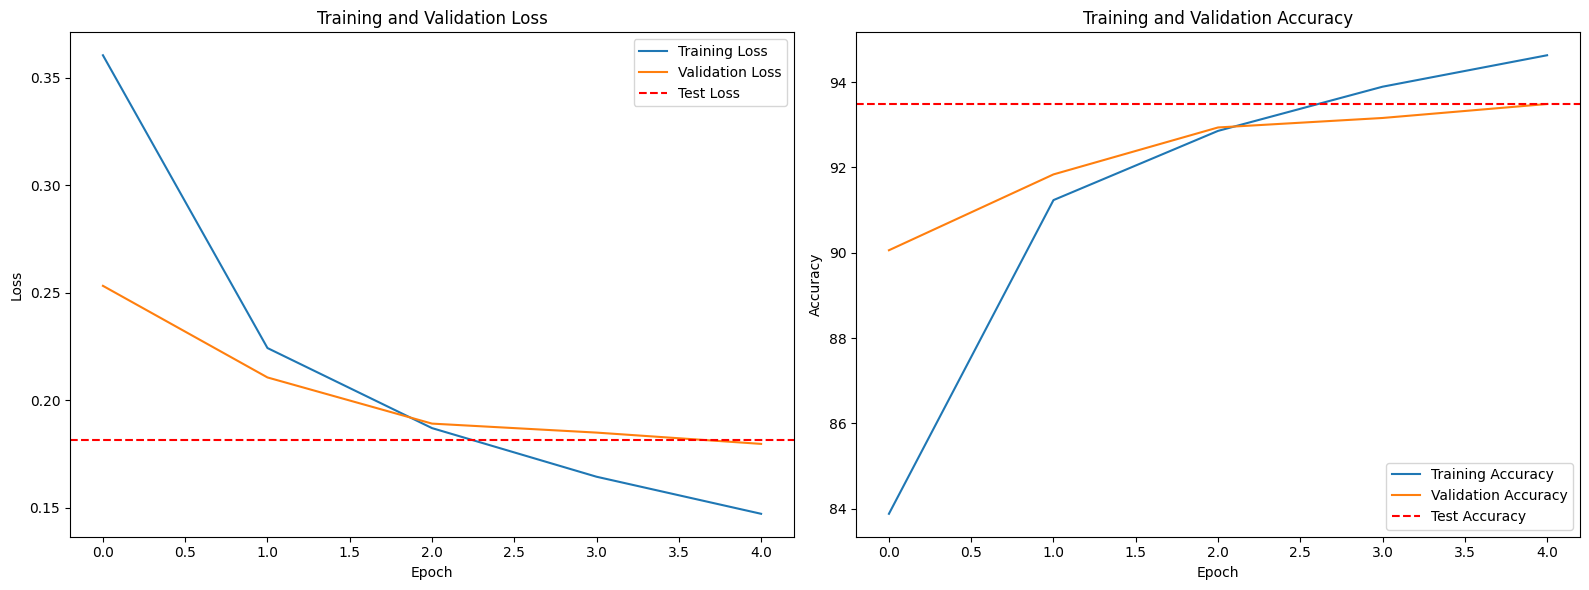

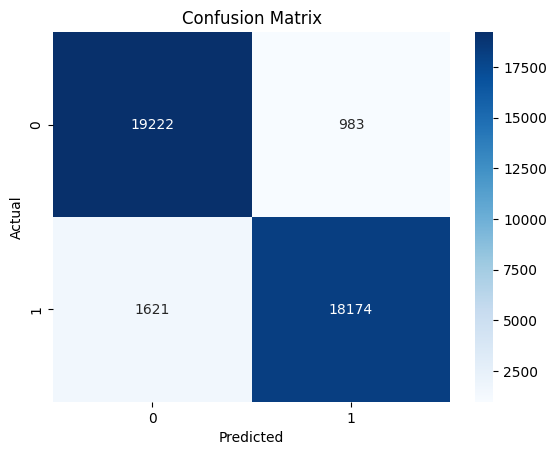

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(train_loss, label='Training Loss')
ax1.plot(validation_loss, label='Validation Loss')
ax1.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accuracy, label='Training Accuracy')
ax2.plot(validation_accuracy, label='Validation Accuracy')
ax2.axhline(y=test_accuracy, color='r', linestyle='--', label='Test Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(labels_test_total_np, predicted_test_classes_np)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<span style='color:green'>### YOUR ANSWER ###</span>

4. Save the weights of the trained neural network

In [24]:
torch.save(model.state_dict(), 'base_model.pth')

## Step 3: Improved LSTM Model

1. Improve your baseline LSTM model

In [25]:
import torch
import torch.nn as nn

class StackedGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=3, drop_prob=0.5):
        super(StackedGRU, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.gru_layers = nn.ModuleList()
        for i in range(num_layers):
            input_dim = embedding_dim if i == 0 else hidden_dim 
            self.gru_layers.append(nn.GRU(input_dim, hidden_dim, num_layers=1, batch_first=True))

        self.dropout = nn.Dropout(drop_prob)

        self.fc1 = nn.Linear(hidden_dim, 32)
        self.batch_norm = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, output_dim)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        for gru in self.gru_layers:
            x, _ = gru(x)
            x = self.dropout(x)

        x = x[:, -1, :]

        x = self.fc1(x)
        x = self.batch_norm(x)
        x = torch.nn.functional.leaky_relu(x)
        x = self.fc2(x)
        return self.activation(x)


2. Create a new class for your improved model

In [26]:
VOCAB_SIZE = len(word_to_index) + 1  
EMBEDDING_DIM = 230  
HIDDEN_DIM = 128
OUTPUT_DIM = 1       
N_LAYERS = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = StackedGRU(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM,
                       hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM, 
                       num_layers=N_LAYERS, drop_prob=0.5).to(device)

print(model2)

StackedGRU(
  (embedding): Embedding(150095, 230)
  (gru_layers): ModuleList(
    (0): GRU(230, 128, batch_first=True)
    (1-2): 2 x GRU(128, 128, batch_first=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (batch_norm): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (activation): Sigmoid()
)


In [27]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.0001)

3. Follow the same training and evaluation procedures

In [28]:
import time

train_loader = create_dataloader(X_train, y_train, batch_size=32)
val_loader = create_dataloader(X_val, y_val, batch_size=32)
test_loader = create_dataloader(X_test, y_test, batch_size=32)

train_loss_2, train_accuracy_2 = [], []
validation_loss_2, validation_accuracy_2 = [], []

best_val_loss = float('inf')
early_stopping_counter = 0
early_stopping_patience = 2
num_epochs = 5

start_training_time = time.time()

for epoch in range(num_epochs):
    
    epoch_start_time = time.time()  
    train_loss_epoch, train_acc = train_one_epoch(model2, train_loader, criterion, optimizer, device)
    val_loss_epoch, val_acc = validate(model2, val_loader, criterion, device)
    epoch_end_time = time.time()  
    epoch_duration = epoch_end_time - epoch_start_time

    # Store metrics
    train_loss_2.append(train_loss_epoch)
    train_accuracy_2.append(train_acc)
    validation_loss_2.append(val_loss_epoch)
    validation_accuracy_2.append(val_acc)

    # Logging
    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss_epoch:.4f}, Train Accuracy: {train_acc:.2f}% | "
          f"Val Loss: {val_loss_epoch:.4f}, Val Accuracy: {val_acc:.2f}% | "
          f"Time: {epoch_duration:.2f} sec")

    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

end_training_time = time.time()
total_training_time = end_training_time - start_training_time
print(f"\nTotal Training Time: {total_training_time:.2f} sec ({total_training_time/60:.2f} min)")

Epoch [1/5] - Train Loss: 0.3632, Train Accuracy: 83.17% | Val Loss: 0.2402, Val Accuracy: 90.75% | Time: 203.55 sec
Epoch [2/5] - Train Loss: 0.2166, Train Accuracy: 91.58% | Val Loss: 0.2060, Val Accuracy: 91.94% | Time: 204.61 sec
Epoch [3/5] - Train Loss: 0.1821, Train Accuracy: 93.11% | Val Loss: 0.1809, Val Accuracy: 93.03% | Time: 204.05 sec
Epoch [4/5] - Train Loss: 0.1606, Train Accuracy: 94.06% | Val Loss: 0.1747, Val Accuracy: 93.53% | Time: 204.09 sec
Epoch [5/5] - Train Loss: 0.1439, Train Accuracy: 94.80% | Val Loss: 0.1673, Val Accuracy: 93.72% | Time: 204.68 sec

Total Training Time: 1020.98 sec (17.02 min)


4. Directly compare the performance of your improved model to the baseline model

In [29]:
labels_test_total_2, test_predictions_2, test_probabilities_2, test_loss_2, test_accuracy_2 = test_model(model2, test_loader, criterion, device)


Test Accuracy: 93.83%
Test Loss: 0.1662


In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

predicted_test_classes_np_2 = np.array([prediction.item() for prediction in test_predictions_2])
labels_test_total_np_2 = np.array([label.item() for label in labels_test_total_2])

precision = precision_score(labels_test_total_np_2, predicted_test_classes_np_2)
recall = recall_score(labels_test_total_np_2, predicted_test_classes_np_2)
f1 = f1_score(labels_test_total_np_2, predicted_test_classes_np_2)

print("Precision 2:", precision)
print("Recall 2:", recall)
print("F1-score 2:", f1)

Precision 2: 0.937970780041454
Recall 2: 0.9373074008588027
F1-score 2: 0.9376389731150191


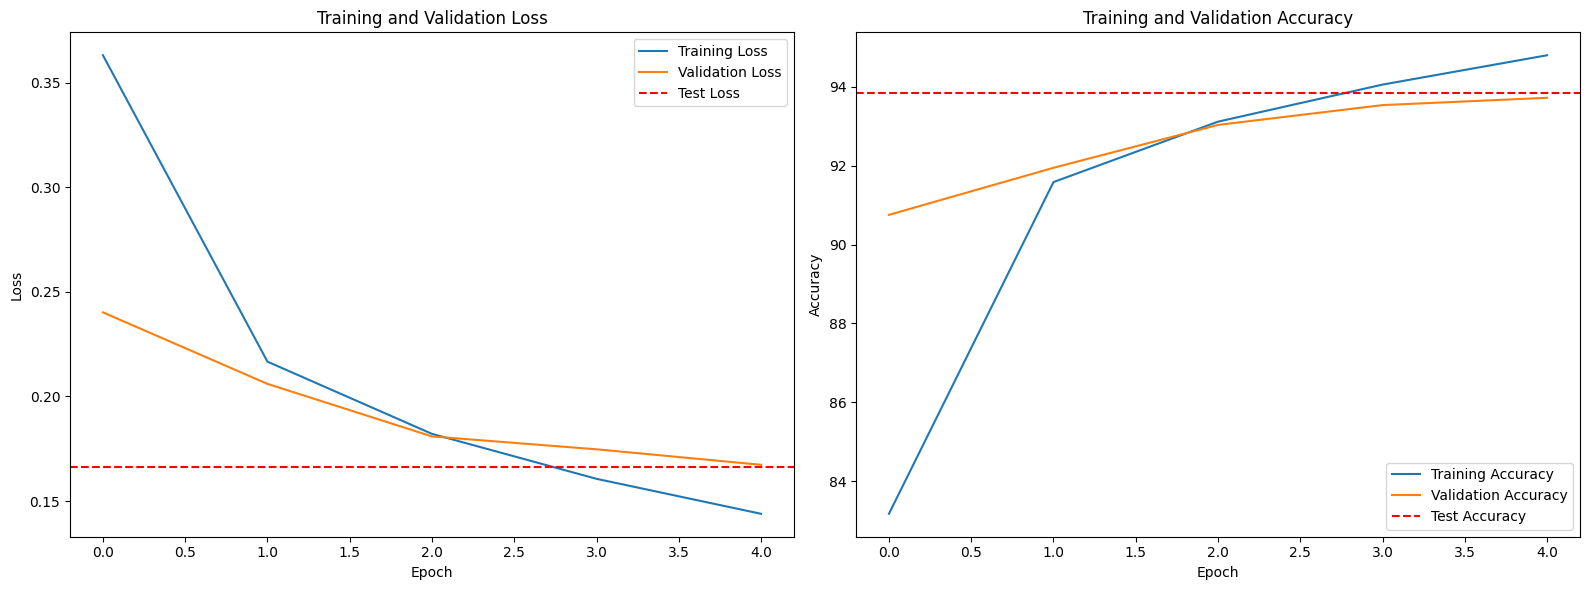

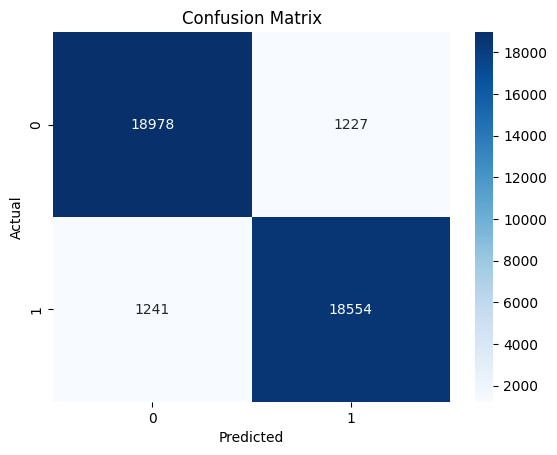

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(train_loss_2, label='Training Loss')
ax1.plot(validation_loss_2, label='Validation Loss')
ax1.axhline(y=test_loss_2, color='r', linestyle='--', label='Test Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accuracy_2, label='Training Accuracy')
ax2.plot(validation_accuracy_2, label='Validation Accuracy')
ax2.axhline(y=test_accuracy_2, color='r', linestyle='--', label='Test Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

# Plot confusion matrix
cm = confusion_matrix(labels_test_total_np_2, predicted_test_classes_np_2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

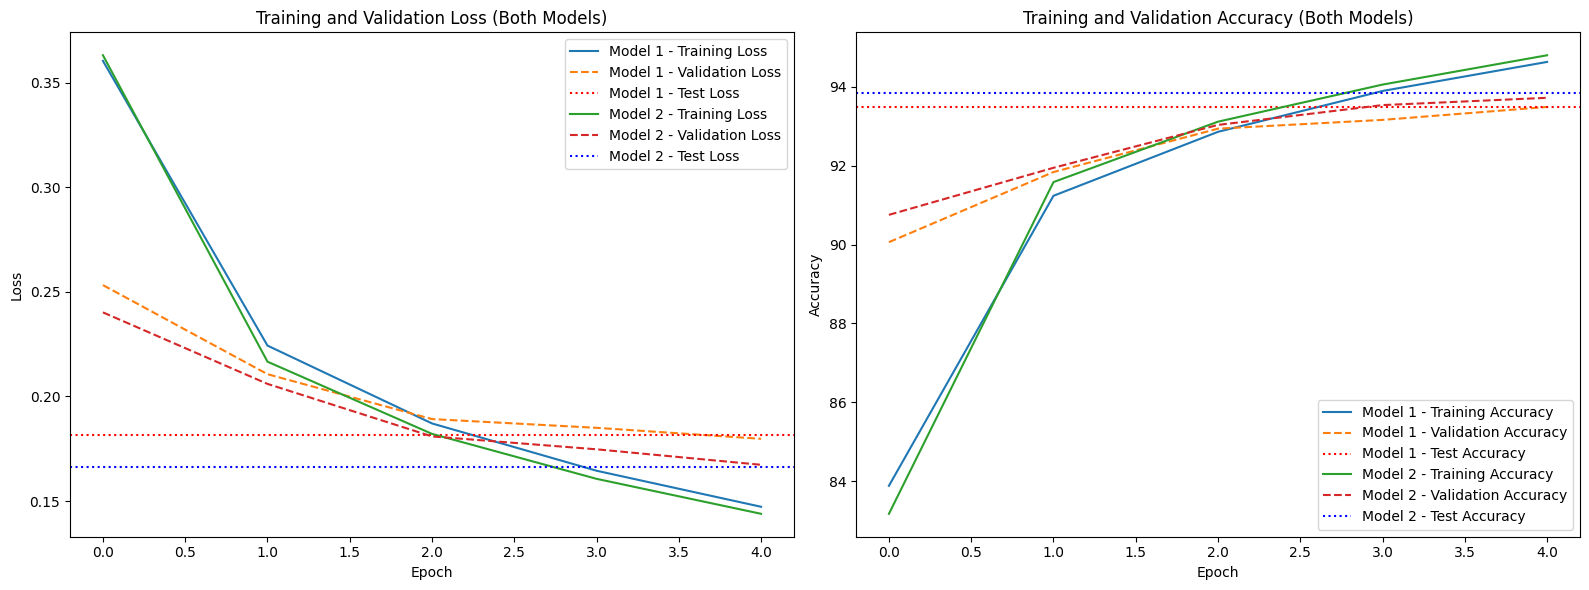

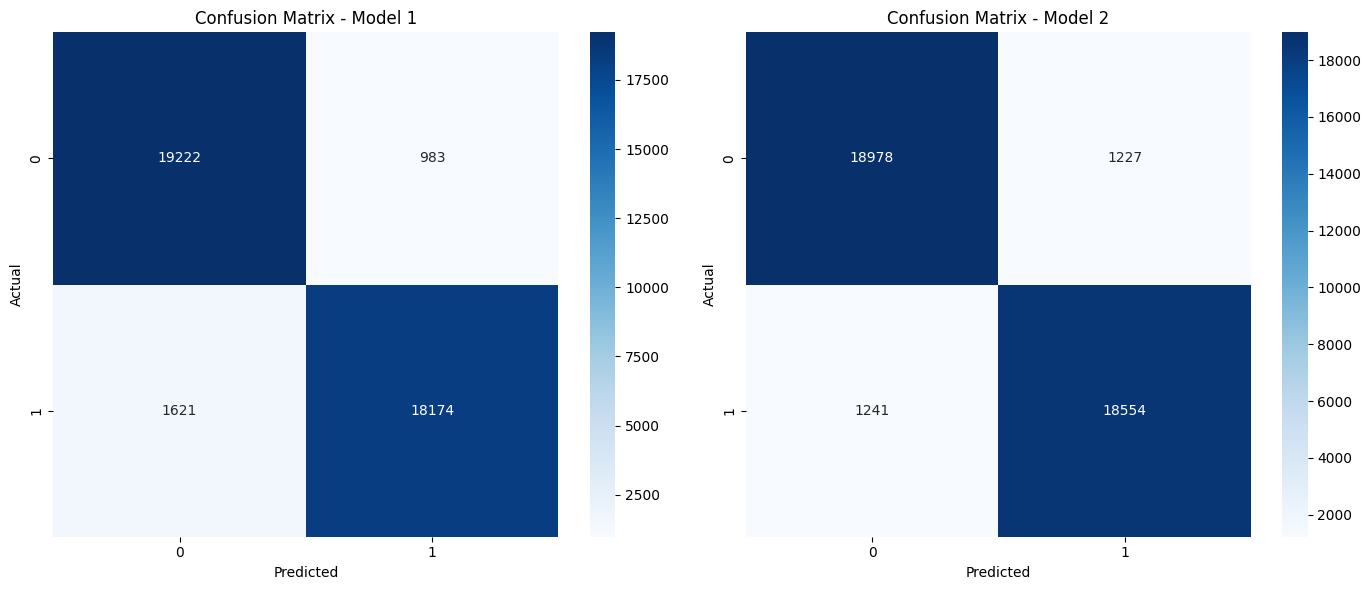

In [32]:
epochs = 5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Loss Plot
ax1.plot(train_loss, label='Model 1 - Training Loss', linestyle='-')
ax1.plot(validation_loss, label='Model 1 - Validation Loss', linestyle='--')
ax1.axhline(y=test_loss, color='r', linestyle=':', label='Model 1 - Test Loss')

ax1.plot(train_loss_2, label='Model 2 - Training Loss', linestyle='-')
ax1.plot(validation_loss_2, label='Model 2 - Validation Loss', linestyle='--')
ax1.axhline(y=test_loss_2, color='b', linestyle=':', label='Model 2 - Test Loss')

ax1.set_title('Training and Validation Loss (Both Models)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accuracy, label='Model 1 - Training Accuracy', linestyle='-')
ax2.plot(validation_accuracy, label='Model 1 - Validation Accuracy', linestyle='--')
ax2.axhline(y=test_accuracy, color='r', linestyle=':', label='Model 1 - Test Accuracy')

ax2.plot(train_accuracy_2, label='Model 2 - Training Accuracy', linestyle='-')
ax2.plot(validation_accuracy_2, label='Model 2 - Validation Accuracy', linestyle='--')
ax2.axhline(y=test_accuracy_2, color='b', linestyle=':', label='Model 2 - Test Accuracy')

ax2.set_title('Training and Validation Accuracy (Both Models)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))

cm1 = confusion_matrix(labels_test_total_np, predicted_test_classes_np)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_title('Confusion Matrix - Model 1')

cm2 = confusion_matrix(labels_test_total_np_2, predicted_test_classes_np_2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=ax4)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.set_title('Confusion Matrix - Model 2')

plt.tight_layout()
plt.show()


<span style='color:green'>### YOUR ANSWER ###</span>

5. Save the weights of the trained neural network

In [33]:
torch.save(model2.state_dict(), 'improved_model.pth')

## Step 4: Discussion

1. Briefly describe the dataset and its key characteristics

<span style='color:green'>ans.</span>

Bittlingmayer's Amazon Reviews Dataset on Kaggle is of Amazon customer reviews designed for sentiment analysis and natural language processing applications.

Important Features:

Size:
Descriptive Statistics for Amazon Reviews - Test Dataset:
• Number of Samples: 400000
• Class Distribution: {'__label__2': 50.0, '__label__1': 50.0}
• Average Review Length (Words): 78.42
• Average Review Length (Characters): 432.43
• Vocabulary Size: 1077182

Format: Each review is saved as a text line in a straightforward, structured format, and the dataset is compressed into a .bz2 file.

Labels: Every review has a binary label that indicates whether it is positive (4,5 star review) or negative (1,2 star review).
Generally, labels appear in the first character of each line; a negative review is denoted by __label__1 and a favourable review by __label__2.

Text Content: Before analysis, the reviews must be preprocessed (e.g., tokenised, stopword removed) because they are in unstructured, raw text.

Use Cases:
Sentiment Analysis (Positive/Negative classification).
Text Preprocessing (Tokenization, Lemmatization, etc.).
Embedding Training (e.g., Word2Vec, FastText, Transformer-based models).
Transfer Learning for NLP applications.

2. Describe both your baseline and improved LSTM architectures in detail

<span style='color:green'>ans.</span> 

The BaseLSTM model is a multi-layered Long Short-Term Memory (LSTM) network for sequence modeling.

Architecture Details:
Embedding Layer:

The model starts with an embedding layer of size (150095, 230), meaning it maps a vocabulary of 150,095 unique words into 230-dimensional word vectors.
LSTM Layers:

Three stacked LSTMs are used to process sequential text data:
LSTM1: Input size = 230, Hidden size = 128, 3 layers.
LSTM2: Input size = 128, Hidden size = 64, 3 layers.
LSTM3: Input size = 64, Hidden size = 32, 3 layers.
Each LSTM layer includes dropout (0.5) to prevent overfitting.
Fully Connected (FC) Layer:

Linear Layer: Maps the 32-dimensional LSTM output to a single output neuron.
Activation Function: Uses Sigmoid activation, indicating a binary classification problem (likely sentiment analysis).
Key Characteristics:
LSTM layers allow the model to learn long-term dependencies.
Uses dropout (0.5) in all LSTM layers to improve generalization.
The final linear layer with sigmoid activation suggests binary classification (e.g., sentiment analysis).

The StackedGRU model is an improved version of BaseLSTM that replaces LSTM layers with Stacked Gated Recurrent Units (GRUs) and incorporates batch normalization.

Architecture Details:
Embedding Layer:
Same as BaseLSTM: (150095, 230), mapping vocabulary to a 230-dimensional vector space.
GRU Layers:

A modular list of GRU layers:
First GRU layer: Input = 230, Hidden = 128, batch_first=True.
Next two GRU layers: Input = 128, Hidden = 128, batch_first=True.
Unlike BaseLSTM, the GRU layers share the same hidden size (128).
GRUs have fewer parameters than LSTMs and are computationally efficient.
Fully Connected Layers with Batch Normalization:

Dropout Layer: p=0.3 (reducing overfitting).
First Linear Layer: Maps 128 → 32.
Batch Normalization: Applied to stabilize learning and improve generalization.
Second Linear Layer: Maps 32 → 1.
Activation Function: Uses Sigmoid (binary classification).
Key Improvements over BaseLSTM:
Uses GRUs instead of LSTMs, making it faster and more memory-efficient.
Includes Batch Normalization, which:
Helps stabilize training.
Improves gradient flow in deep networks.
Uses Dropout (0.3) instead of 0.5, reducing aggressive regularization.

3. Discuss the results, comparing the performance of the baseline and improved models

<span style='color:green'>ans.</span>

Loss Analysis

Both models show decreasing training and validation loss, indicating successful learning.
Model 2 has a slightly lower validation loss than Model 1, suggesting better generalization.
The test loss of Model 2 is lower than Model 1, indicating a reduced gap between training and real-world performance.

Accuracy Analysis

Both models improve in accuracy across epochs, with Model 2 achieving a higher final validation and test accuracy.
Model 2 converges faster, meaning it learns better features in fewer epochs.
The test accuracy of Model 2 is higher than Model 1, indicating better generalization to unseen data.

Model 1 Confusion Matrix

True Negatives (TN): 19,222
False Positives (FP): 983 → Model incorrectly classified 983 negatives as positives.
False Negatives (FN): 1,621 → Model failed to identify 1,621 positives.
True Positives (TP): 18,174
Model 2 Confusion Matrix

True Negatives (TN): 18,978
False Positives (FP): 1,227
False Negatives (FN): 1,241 → Lower FN than Model 1, meaning Model 2 captures more true positives.
True Positives (TP): 18,554

Model 2 outperforms Model 1 in both accuracy and recall, making it a better classifier.
Lower validation and test loss indicate that Model 2 generalizes better.
Lower FN in Model 2 means it is better at capturing positives, which is crucial in many applications

4. Discuss the strengths and limitations of using recurrent neural models for sentiment analysis

<span style='color:green'>ans.</span>

Strengths and Limitations of Using Recurrent Neural Models for Sentiment Analysis
Recurrent Neural Networks (RNNs), particularly LSTM (Long Short-Term Memory) and GRU (Gated Recurrent Unit) models, are widely used for sentiment analysis due to their ability to handle sequential data. However, they come with both advantages and challenges.

1. Strengths

a) RNNs process text word by word while preserving sentence context. Gating methods are used by LSTM and GRU models to preserve long-term dependencies and avoid data loss in lengthy sequences.
b) RNNs don't need fixed input lengths like standard models do. They are perfect for lengthy evaluations or brief tweets because they dynamically adjust to sentence length.
c) Textual sentiment is frequently influenced by changes in context. Compared to conventional models, LSTMs and GRUs are better at capturing these dependencies.
d) Word semantics can be better understood by using RNNs with word embeddings such as Word2Vec, GloVe, or Transformer-based embeddings.
e) Pretrained LSTM/GRU models on large sentiment datasets can be fine-tuned for different sentiment-related tasks with minimal labeled data.

2. Limitations

a) LSTMs and GRUs require sequential processing, which limits parallelization.
Training deep recurrent networks is slower compared to CNNs or Transformer models.
b) Despite LSTMs' ability to retain long-term information, they still suffer from vanishing gradient issues in very long sequences.
c) LSTMs and GRUs contain a large number of parameters, making them prone to overfitting on small datasets. Requires dropout regularization and batch normalization to generalize well.
d) If the model's embedding layer was trained on a different dataset, it may struggle with unseen words/slang. Does not handle rare words or new expressions well unless pretrained embeddings are used.
e) If sentiment shifts significantly within a long text, LSTMs might fail to correctly capture the final sentiment.
f) Modern NLP models like BERT, RoBERTa, GPT have largely replaced LSTMs for sentiment analysis.
Transformers use self-attention mechanisms to capture long-term dependencies efficiently and can process text in parallel, making them faster and more effective.

5. References. Include details on all the resources used to complete this part.

<span style='color:green'>ans.</span>

a0_part_1_dshrisai_sashikum.ipynb from Assignment 1: CSE 676

https://www.kaggle.com/datasets/bittlingmayer/amazonreviews/data

https://wiki.python.org/moin/

https://pytorch.org/tutorials/beginner/saving_loading_models.html

https://pytorch.org/docs/stable/optim.html

https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html

https://pytorch.org/docs/stable/generated/torch.nn.GRU.html